In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os

plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams.update({'font.size': 12})

# Wczytanie danych
mat_contents = scipy.io.loadmat('allFaces.mat')

faces = mat_contents['faces']
m = int(mat_contents['m'].item())
n = int(mat_contents['n'].item())
nfaces = mat_contents['nfaces'].flatten()

print("Rozmiar danych:", faces.shape)

Rozmiar danych: (32256, 2410)


In [2]:
# 30 pierwszych twarzy jako zbior do treningu
num_people_train = 30
trainingFaces = faces[:, :np.sum(nfaces[:num_people_train])]

print("Rozmiar zbioru treningowego:", trainingFaces.shape)

Rozmiar zbioru treningowego: (32256, 1898)


In [3]:
avgFace = np.mean(trainingFaces, axis=1)

X = trainingFaces - np.tile(avgFace, (trainingFaces.shape[1], 1)).T

In [4]:
U, S, VT = np.linalg.svd(X, full_matrices=False)

print("Rozmiar U:", U.shape)
print("Liczba wartości singularnych:", len(S))

Rozmiar U: (32256, 1898)
Liczba wartości singularnych: 1898


Minimalne r dla 95% wariancji: 1292


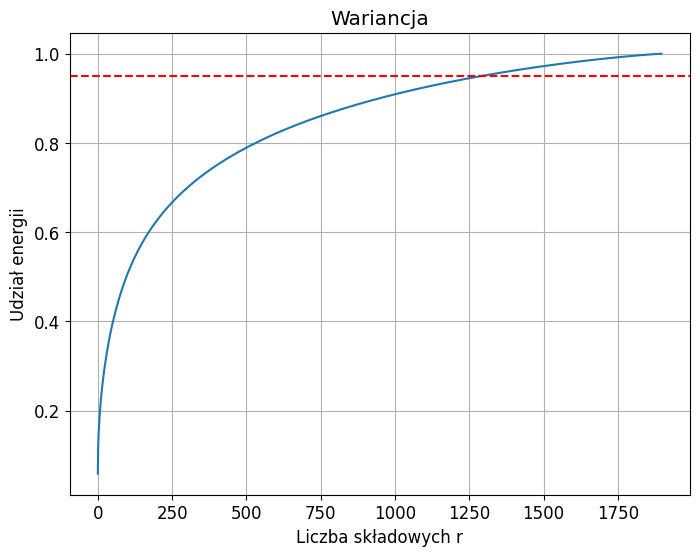

In [5]:
# skumulowana wariancja/energia
cum_energy = np.cumsum(S) / np.sum(S)

# wyznaczenie min r dla 95%
k = 0.95
r = np.argmax(cum_energy >= k) + 1

print("Minimalne r dla 95% wariancji:", r)

# wykres
plt.plot(cum_energy)
plt.axhline(y=k, color='r', linestyle='--')
plt.title("Wariancja")
plt.xlabel("Liczba składowych r")
plt.ylabel("Udział energii")
plt.grid(True)
plt.show()

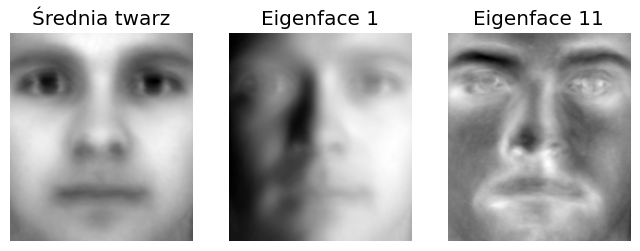

In [6]:
fig, axes = plt.subplots(1, 3)

axes[0].imshow(avgFace.reshape(m, n).T, cmap='gray')
axes[0].set_title("Średnia twarz")
axes[0].axis('off')

axes[1].imshow(U[:,0].reshape(m, n).T, cmap='gray')
axes[1].set_title("Eigenface 1")
axes[1].axis('off')

axes[2].imshow(U[:,10].reshape(m, n).T, cmap='gray')
axes[2].set_title("Eigenface 11")
axes[2].axis('off')

plt.show()

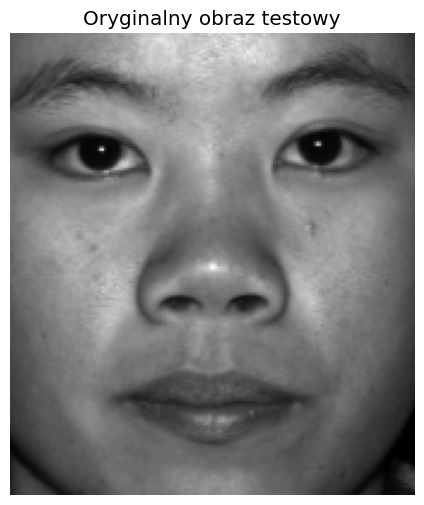

In [7]:
# wybor twarzy spoza zbioru treningowego
person_test = 36

start_idx = np.sum(nfaces[:(person_test-1)])

# zabezpieczenie na max liczbe w zbiorze
if start_idx >= faces.shape[1]:
    start_idx = faces.shape[1] - 1
    
testFace = faces[:, start_idx]

plt.imshow(testFace.reshape(m, n).T, cmap='gray')
plt.title("Oryginalny obraz testowy")
plt.axis('off')
plt.show()

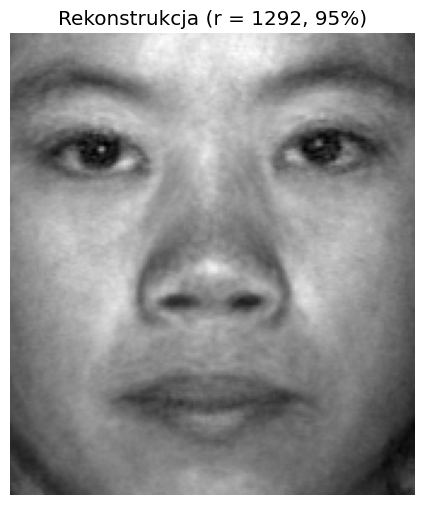

In [8]:
testFaceMS = testFace - avgFace

Ur = U[:, :r]

reconFace = avgFace + Ur @ (Ur.T @ testFaceMS)

plt.imshow(reconFace.reshape(m, n).T, cmap='gray')
plt.title(f"Rekonstrukcja (r = {r}, 95%)")
plt.axis('off')
plt.show()

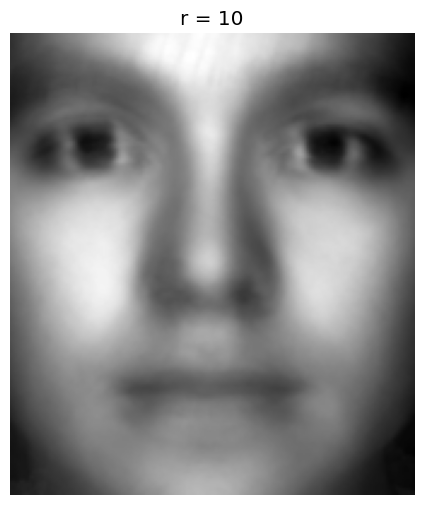

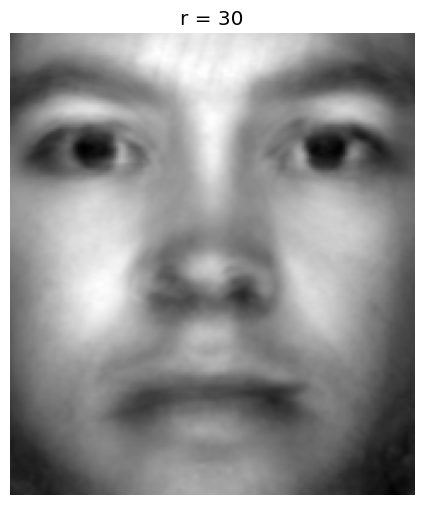

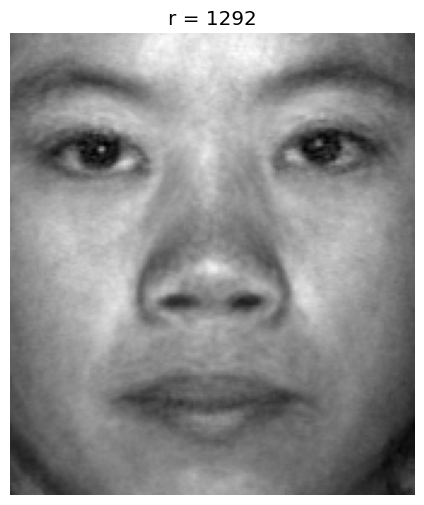

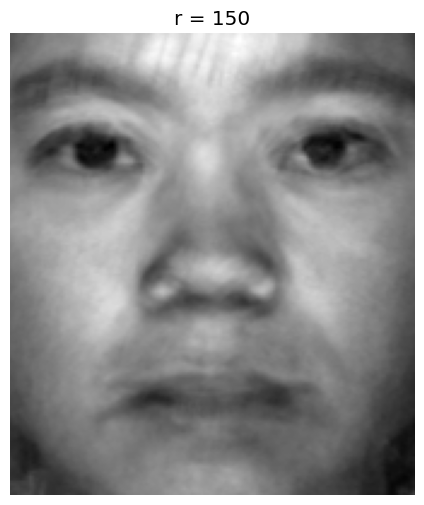

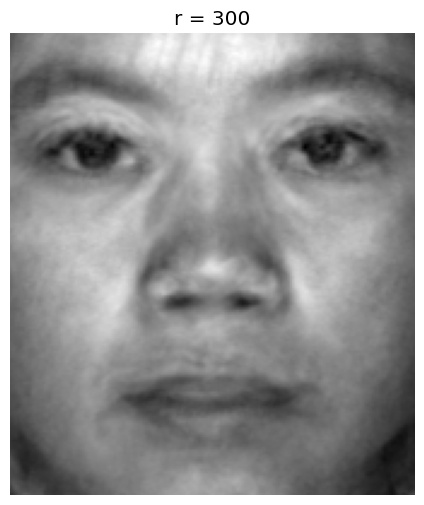

In [9]:
r_list = [10, 30, r, 150, 300]

for r_val in r_list:
    Ur = U[:, :r_val]
    recon = avgFace + Ur @ (Ur.T @ testFaceMS)

    plt.imshow(recon.reshape(m, n).T, cmap='gray')
    plt.title(f"r = {r_val}")
    plt.axis('off')
    plt.show()

In [10]:
Dla wartości r=1292 udało się zachować co najmniej 95 % informacji zawartej w danych. 
Rekonstrukcja przy tej liczbie eigenfaces wizualnie jest bardzo zbliżona do zdjęcia oryginalnego
Większe r poprawi jakość rekonstrukcji, ale zwiększy złożoność modelu.

SyntaxError: invalid syntax (119522315.py, line 1)